# Regression Analysis: News Topics → Stock Returns
## Chen (2025) Framework - BERTopic Integration

**Objective**: Analyze impact of news topics on stock returns for 30 G-SIB banks

### Workflow:
1. Load stock returns from `Data/eodhd_tickers_performance.csv`
2. Load topic assignments from BERTopic output folder
3. Merge on date and extract topic information from headline metadata
4. Aggregate topics to daily level per ticker
5. Run panel regression: `return ~ topics + market_controls`
6. Save results to `Outputs/Regression_Results/`

### Data Sources:
- **Stock Returns**: `Code/Data/eodhd_tickers_performance.csv` (daily OHLCV)
- **Topics**: `Code/Outputs/eodhd_BERTopic_FinLang/*/row_level/row_topic_assignments_all.csv`
- **Stock Tickers**: 30 G-SIB banks (JPM, BAC, C, HSBC, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# For regression
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

# Set paths
base_path = Path('.')
data_path = base_path / 'Data'
output_path = base_path / 'Outputs'
regression_output = base_path / 'Outputs' / 'Regression_Results_FinLang'

# Create output directory
regression_output.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported")
print(f"✓ Output path: {regression_output}")


✓ Libraries imported
✓ Output path: Outputs\Regression_Results_FinLang


## Section 1: Load Stock Returns Data

In [2]:
# Load stock returns data
stock_returns = pd.read_csv(data_path / 'eodhd_tickers_performance.csv')

# Convert date to datetime
stock_returns['date'] = pd.to_datetime(stock_returns['date'])

# Calculate daily returns if not already present
if stock_returns['daily_return'].isna().all():
    stock_returns['daily_return'] = stock_returns.groupby('ticker')['close'].pct_change() * 100
else:
    stock_returns['daily_return'] = stock_returns['daily_return'].fillna(
        stock_returns.groupby('ticker')['close'].pct_change() * 100
    )

# Remove NaN returns (first obs per ticker)
stock_returns = stock_returns.dropna(subset=['daily_return'])

print(f"✓ Stock returns loaded: {stock_returns.shape[0]} records")
print(f"✓ Date range: {stock_returns['date'].min()} to {stock_returns['date'].max()}")
print(f"✓ Unique tickers: {stock_returns['ticker'].nunique()}")
print(f"\nStock returns summary:")
print(stock_returns[['date', 'ticker', 'close', 'daily_return']].head(10))


✓ Stock returns loaded: 80268 records
✓ Date range: 2014-02-19 00:00:00 to 2026-05-08 00:00:00
✓ Unique tickers: 27

Stock returns summary:
         date ticker     close  daily_return
26 2014-02-19  ACGBY   11.2500     -0.846113
27 2014-02-19    BAC   16.2000     -1.639344
28 2014-02-19  BACHY   10.5125     -0.355450
29 2014-02-19    BCS   17.0300     -4.492177
30 2014-02-19     BK   31.1300     -1.983627
31 2014-02-19  BNPQY   39.8500     -1.018381
32 2014-02-19      C   48.1900     -2.409883
33 2014-02-19  CICHY   14.0030      0.000000
34 2014-02-19     DB   43.1696     -2.105755
35 2014-02-19     GS  163.2600     -0.844215


## Section 2: Load Topic Assignments from Output Folder

In [3]:
# Specifically use eodhd_BERTopic_FinLang folder
bertopic_folder = output_path / 'eodhd_BERTopic_FinLang'

if not bertopic_folder.exists():
    raise FileNotFoundError(f"BERTopic folder not found: {bertopic_folder}")

# Find the timestamp subfolder (most recent if multiple exist)
timestamp_folders = list(bertopic_folder.glob('*/'))
if not timestamp_folders:
    raise FileNotFoundError(f"No timestamp subfolder found in {bertopic_folder}")

timestamp_folder = sorted(timestamp_folders, key=lambda x: os.path.getmtime(x), reverse=True)[0]
topics_file = timestamp_folder / 'row_level' / 'row_topic_assignments_all.csv'

print(f"Loading topics from: {topics_file}")

# Load topics
topics_df = pd.read_csv(topics_file)

# Parse date from topics_df (assuming it has a date column)
topics_df['date'] = pd.to_datetime(topics_df['date'])

# IMPORTANT: The row_topic_assignments_all.csv does NOT have ticker info
# We need to merge it back from the original model input data
print(f"✓ Topics columns: {list(topics_df.columns)}")
print(f"✓ Topics shape: {topics_df.shape}")

# Load the original model input to get ticker mapping
model_input = pd.read_csv(data_path / 'eodhd_model_input.csv')
model_input['date'] = pd.to_datetime(model_input['date'])
print(f"\nModel input columns: {list(model_input.columns)}")

# Create a mapping of (date, headline) -> ticker
# Note: Some headlines appear multiple times across different tickers
# We'll keep one ticker per headline for simplicity (first occurrence)
headline_ticker_map = model_input.groupby('headline').first()[['stock']].reset_index()
headline_ticker_map = headline_ticker_map.rename(columns={'stock': 'ticker'})

print(f"\nHeadline-to-ticker mapping: {len(headline_ticker_map)} unique headlines")

# Merge ticker into topics
topics_df = topics_df.merge(headline_ticker_map, on='headline', how='left')

# Check how many we matched
matched = topics_df['ticker'].notna().sum()
total = len(topics_df)
print(f"Matched {matched}/{total} headlines to tickers ({100*matched/total:.1f}%)")

# Remove rows without ticker match
topics_with_ticker = topics_df[topics_df['ticker'].notna()].copy()
print(f"Topics with ticker: {len(topics_with_ticker)}")

print(f"\nTicker distribution in topics:")
print(topics_with_ticker['ticker'].value_counts().head(10))


Loading topics from: Outputs\eodhd_BERTopic_FinLang\20260505_023635\row_level\row_topic_assignments_all.csv
✓ Topics columns: ['split', 'row_index', 'date', 'headline', 'topic']
✓ Topics shape: (65402, 5)

Model input columns: ['stock', 'date', 'date_only', 'headline', 'headline_raw']

Headline-to-ticker mapping: 65402 unique headlines
Matched 65402/65402 headlines to tickers (100.0%)
Topics with ticker: 65402

Ticker distribution in topics:
ticker
JPM     11167
GS       7228
BAC      6909
C        5389
MS       5350
HSBC     4988
WFC      4145
UBS      3583
BCS      2482
SAN      1793
Name: count, dtype: int64


## Section 3: Aggregate Topics to Daily Level per Ticker

In [4]:
# Use the topics_with_ticker from Section 2 (already has ticker from model_input merge)
print(f"Topics with ticker: {len(topics_with_ticker)}")
print(f"Columns: {list(topics_with_ticker.columns)}")
print(f"Date range: {topics_with_ticker['date'].min()} to {topics_with_ticker['date'].max()}")
print(f"\nTicker distribution:")
print(topics_with_ticker['ticker'].value_counts())


Topics with ticker: 65402
Columns: ['split', 'row_index', 'date', 'headline', 'topic', 'ticker']
Date range: 2015-01-05 00:00:00+00:00 to 2026-05-01 14:06:17+00:00

Ticker distribution:
ticker
JPM      11167
GS        7228
BAC       6909
C         5389
MS        5350
HSBC      4988
WFC       4145
UBS       3583
BCS       2482
SAN       1793
RY        1508
STT       1489
TD        1401
DB        1386
BK        1359
ING        993
BNPQY      918
MUFG       863
SCBFF      583
SCGLY      533
MFG        470
SMFG       381
BACHY      179
IDCBY      138
CICHY       64
BCMXY       54
ACGBY       49
Name: count, dtype: int64


## Section 4: Pivot Topics to Daily Level per Ticker

In [5]:
# Aggregate topics to daily level (count of articles per topic per day/ticker)
topics_daily = topics_with_ticker.groupby(['date', 'ticker', 'topic']).size().reset_index(name='article_count')

# Remove topic -1 (outliers/noise from BERTopic)
print(f"Removing topic -1 (outliers)...")
topics_before = topics_daily.shape[0]
topics_daily = topics_daily[topics_daily['topic'] != -1]
topics_after = topics_daily.shape[0]
print(f"  Rows removed: {topics_before - topics_after:,}")

# Also get total articles per day/ticker
total_articles = topics_with_ticker.groupby(['date', 'ticker']).size().reset_index(name='total_articles')

# Calculate topic prevalence (proportion)
topics_daily = topics_daily.merge(total_articles, on=['date', 'ticker'])
topics_daily['topic_prevalence'] = topics_daily['article_count'] / topics_daily['total_articles']

# Pivot to get one row per date-ticker with topic columns
# Method: Create separate column for each topic
topic_pivot = topics_daily.pivot_table(
    index=['date', 'ticker'],
    columns='topic',
    values='topic_prevalence',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Rename columns for clarity
topic_pivot.columns.name = None
topic_pivot = topic_pivot.rename(columns={col: f'topic_{col}' for col in topic_pivot.columns if isinstance(col, (int, np.integer))})

# Also add total article count
topic_pivot = topic_pivot.merge(total_articles[['date', 'ticker', 'total_articles']], on=['date', 'ticker'])

print(f"✓ Topics aggregated to daily level (excluding topic -1): {topic_pivot.shape[0]} records")
print(f"✓ Topic columns: {len([c for c in topic_pivot.columns if c.startswith('topic_')])}")
print(f"\nTopic prevalence data sample:")
print(topic_pivot.head())


Removing topic -1 (outliers)...
  Rows removed: 28,774


✓ Topics aggregated to daily level (excluding topic -1): 35989 records
✓ Topic columns: 638

Topic prevalence data sample:
                       date ticker  topic_0  topic_1  topic_2  topic_3  \
0 2015-07-14 23:00:00+00:00    BAC      1.0      0.0      0.0      0.0   
1 2015-07-17 00:00:00+00:00   SMFG      0.0      0.0      0.0      0.0   
2 2015-07-28 15:00:00+00:00    BAC      0.0      0.0      0.0      0.0   
3 2015-07-31 00:00:00+00:00   SMFG      0.0      0.0      0.0      0.0   
4 2015-08-12 15:00:00+00:00    ING      0.0      0.0      0.0      0.0   

   topic_4  topic_5  topic_6  topic_7  ...  topic_629  topic_630  topic_631  \
0      0.0      0.0      0.0      0.0  ...        0.0        0.0        0.0   
1      0.0      0.0      0.0      0.0  ...        0.0        0.0        0.0   
2      0.0      0.0      0.0      0.0  ...        0.0        0.0        0.0   
3      0.0      0.0      0.0      0.0  ...        0.0        0.0        0.0   
4      0.0      0.0      0.0      0.0

## Section 5: Merge Stock Returns with Topic Data

In [6]:
# Select only necessary columns from stock returns
stock_returns_merge = stock_returns[['date', 'ticker', 'close', 'daily_return']].copy()

# Ensure both dataframes have the same datetime format (remove timezone info)
stock_returns_merge['date'] = stock_returns_merge['date'].dt.tz_localize(None)
topic_pivot['date'] = topic_pivot['date'].dt.tz_localize(None)

# IMPORTANT: Chen (2025) Framework - Convert Topic Prevalence to Binary Dummies
# Per Chen 3.4: "Topic labels are transformed into dummy variables representing 
# the presence of each topic on a given day"
# Specification: Rt = α + Σ(βk * Dt,k) + ϵt
# Where Dt,k is binary (1 if topic present, 0 otherwise)

# Create lagged date for topics (shift forward by 1 day)
topic_pivot_lagged = topic_pivot.copy()
topic_pivot_lagged['merge_date'] = topic_pivot_lagged['date'] + pd.Timedelta(days=1)

# Convert continuous topic prevalence to binary dummies (presence = prevalence > 0)
topic_cols_base = [c for c in topic_pivot_lagged.columns if c.startswith('topic_')]
print(f"Converting {len(topic_cols_base)} topics from prevalence to binary dummies...")

for col in topic_cols_base:
    # Convert: if prevalence > 0, then topic is present (1), else absent (0)
    topic_pivot_lagged[col] = (topic_pivot_lagged[col] > 0).astype(int)

# Rename topic columns to indicate they are lagged dummy variables
topic_cols_lagged = {col: f'{col}_lag1' for col in topic_cols_base}
topic_pivot_lagged = topic_pivot_lagged.rename(columns=topic_cols_lagged)

print(f"✓ Created 1-day lagged binary topic dummies:")
print(f"  Binary topics (0/1): {len(topic_cols_base)} columns")
print(f"  Lagged dummies: {list(topic_cols_lagged.values())[:5]}... (showing first 5)")

# Verify conversion
dummy_cols = list(topic_cols_lagged.values())
print(f"\nBinary dummy verification (first 5 topics, sample rows):")
print(topic_pivot_lagged[['date', 'ticker'] + dummy_cols[:5]].head())

# Merge: tomorrow's stock returns (date t+1) with today's topic dummies (date t)
# stock_returns_merge['date'] is the return date
# topic_pivot_lagged['merge_date'] is the topic date + 1 day
regression_data = stock_returns_merge.merge(
    topic_pivot_lagged[['merge_date', 'ticker', *topic_cols_lagged.values(), 'total_articles']],
    left_on=['date', 'ticker'],
    right_on=['merge_date', 'ticker'],
    how='left'  # Keep all stock records
)

# Drop the merge_date column (redundant with date)
regression_data = regression_data.drop('merge_date', axis=1)

# Fill NaN lagged topic dummies with 0 (topic not present on prior day)
topic_cols = [c for c in regression_data.columns if c.startswith('topic_') and c.endswith('_lag1')]
for col in topic_cols:
    regression_data[col] = regression_data[col].fillna(0).astype(int)

print(f"\n✓ Merged regression data with 1-day lagged binary dummies:")
print(f"✓ Total records: {regression_data.shape[0]}")
print(f"✓ Columns: {regression_data.shape[1]}")
print(f"✓ Binary topic dummy columns: {len(topic_cols)}")
print(f"\nData structure (showing binary dummies - 0/1):")
print(regression_data[['date', 'ticker', 'daily_return', *topic_cols[:3]]].head(10))

# Data quality check
print(f"\nData quality:")
print(f"  Missing daily_return: {regression_data['daily_return'].isna().sum()}")
print(f"  Missing close: {regression_data['close'].isna().sum()}")
print(f"  Topic dummy distribution (% days with topic present):")
for col in topic_cols[:5]:
    pct_present = 100 * regression_data[col].mean()
    print(f"    {col}: {pct_present:.1f}%")
print(f"\n⚠️  Per Chen 3.4: 'Dummy variables are generated using one-hot encoding'")


Converting 638 topics from prevalence to binary dummies...
✓ Created 1-day lagged binary topic dummies:
  Binary topics (0/1): 638 columns
  Lagged dummies: ['topic_0_lag1', 'topic_1_lag1', 'topic_2_lag1', 'topic_3_lag1', 'topic_4_lag1']... (showing first 5)

Binary dummy verification (first 5 topics, sample rows):
                 date ticker  topic_0_lag1  topic_1_lag1  topic_2_lag1  \
0 2015-07-14 23:00:00    BAC             1             0             0   
1 2015-07-17 00:00:00   SMFG             0             0             0   
2 2015-07-28 15:00:00    BAC             0             0             0   
3 2015-07-31 00:00:00   SMFG             0             0             0   
4 2015-08-12 15:00:00    ING             0             0             0   

   topic_3_lag1  topic_4_lag1  
0             0             0  
1             0             0  
2             0             0  
3             0             0  
4             0             0  

✓ Merged regression data with 1-day lagged bi

## Section 6: Exploratory Data Analysis

DAILY RETURNS STATISTICS BY TICKER
         count      mean       std        min       25%       50%       75%  \
ticker                                                                        
ACGBY   3069.0  0.027063  1.436873 -10.188048 -0.713436  0.000000  0.761085   
BAC     3074.0  0.054840  1.891297 -15.397351 -0.870963  0.046421  1.019758   
BACHY   3073.0  0.023790  1.391924 -10.035608 -0.744133  0.000000  0.778210   
BCMXY    950.0  0.074335  2.897109 -20.840728 -0.905819  0.000000  1.174180   
BCS     3074.0  0.036061  2.302357 -21.851852 -1.072197  0.000000  1.171755   
BK      3074.0  0.059608  1.648175 -14.503369 -0.699856  0.114270  0.899880   
BNPQY   3073.0  0.032231  2.109281 -21.436344 -1.017533  0.064662  1.097314   
C       3074.0  0.050783  2.017877 -19.298589 -0.880894  0.044345  0.982250   
CICHY   3069.0  0.025629  1.438785 -11.397059 -0.758747  0.000000  0.764462   
DB      3074.0  0.019983  2.462754 -17.488668 -1.235320  0.000000  1.356711   
GS      3074.0  0

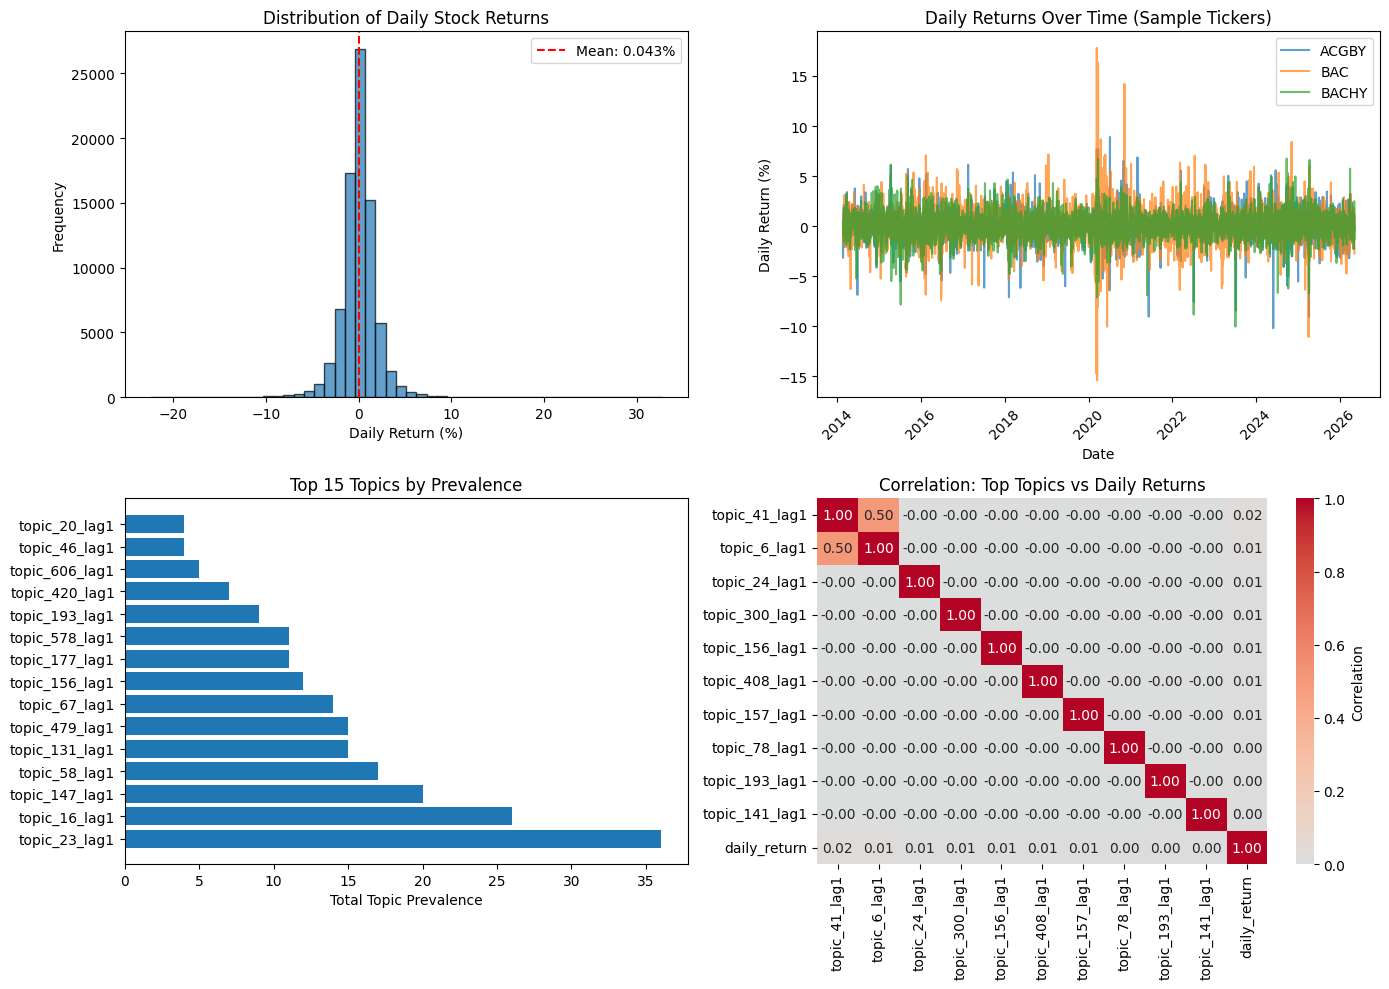

In [7]:
# Summary statistics for daily returns
print("="*70)
print("DAILY RETURNS STATISTICS BY TICKER")
print("="*70)
returns_summary = regression_data.groupby('ticker')['daily_return'].describe()
print(returns_summary)

# Summary statistics for lagged topics (t-1)
print("\n" + "="*70)
print("LAGGED TOPIC PREVALENCE STATISTICS (t-1)")
print("="*70)
topic_summary = regression_data[topic_cols].describe()
print(topic_summary)

# Correlation between lagged topics (t-1) and daily returns (t)
print("\n" + "="*70)
print("CORRELATION: LAGGED TOPICS (t-1) vs DAILY RETURNS (t)")
print("="*70)
correlation_matrix = regression_data[[*topic_cols, 'daily_return']].corr()
topic_return_corr = correlation_matrix[['daily_return']].drop('daily_return').sort_values('daily_return', ascending=False)
print(topic_return_corr)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of daily returns
axes[0, 0].hist(regression_data['daily_return'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Daily Return (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Stock Returns')
axes[0, 0].axvline(regression_data['daily_return'].mean(), color='red', linestyle='--', label=f'Mean: {regression_data["daily_return"].mean():.3f}%')
axes[0, 0].legend()

# Plot 2: Daily returns over time (sample of tickers)
sample_tickers = regression_data['ticker'].unique()[:3]
for ticker in sample_tickers:
    ticker_data = regression_data[regression_data['ticker'] == ticker].sort_values('date')
    axes[0, 1].plot(ticker_data['date'], ticker_data['daily_return'], label=ticker, alpha=0.7)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Daily Return (%)')
axes[0, 1].set_title('Daily Returns Over Time (Sample Tickers)')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Topic prevalence distribution
topic_prevalence_plot = regression_data[topic_cols].sum().sort_values(ascending=False).head(15)
axes[1, 0].barh(range(len(topic_prevalence_plot)), topic_prevalence_plot.values)
axes[1, 0].set_yticks(range(len(topic_prevalence_plot)))
axes[1, 0].set_yticklabels(topic_prevalence_plot.index)
axes[1, 0].set_xlabel('Total Topic Prevalence')
axes[1, 0].set_title('Top 15 Topics by Prevalence')

# Plot 4: Correlation heatmap (top topics)
top_topics = topic_return_corr.head(10).index.tolist()
corr_subset = regression_data[[*top_topics, 'daily_return']].corr()
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Correlation: Top Topics vs Daily Returns')

plt.tight_layout()
plt.savefig(regression_output / '01_eda_summary.png', dpi=300, bbox_inches='tight')
print("✓ EDA visualization saved: 01_eda_summary.png")
plt.show()


## Section 7: Panel Regression Model (OLS with Fixed Effects)

In [8]:
# Prepare data for regression (Chen 2025 Framework)
# Remove first observation per ticker (no prior day topics available)
# Also remove any rows with NaN daily returns
regression_model_data = regression_data.dropna(subset=['daily_return'])
regression_model_data = regression_model_data.dropna(subset=topic_cols, how='all')  # Remove rows with all NaN topics

print(f"✓ Sample size after removing NaN values: {len(regression_model_data)} observations")

# Select top topics (by variance) to avoid multicollinearity
# Keep only topics with meaningful variation
topic_cols_clean = [c for c in topic_cols if regression_model_data[c].std() > 0]

print(f"✓ Topics in model: {len(topic_cols_clean)} (with non-zero variance)")

# Build regression formula - Chen (2025) specification
# Model: return(t) ~ topic_assignment(t-1) + C(ticker)
# Interpretation: Tomorrow's return predicted by today's news topics
formula = f"daily_return ~ {' + '.join(topic_cols_clean)} + C(ticker)"  # Use ALL topics

print(f"\n{'='*70}")
print("REGRESSION SPECIFICATION: Chen (2025) - 1-Day Lag Framework")
print(f"{'='*70}")
print(f"Dependent Variable: daily_return(t) = Return on day t")
print(f"Independent Variables: topic_X_lag1 = Topic assignments from day t-1")
print(f"Fixed Effects: C(ticker) = Bank-specific intercepts")
print(f"Sample: {len(regression_model_data)} observations across {regression_model_data['ticker'].nunique()} banks")
print(f"Total topics in model: {len(topic_cols_clean)}")
print(f"\nFormula (first 300 chars):\n{formula[:300]}...\n")

# Run OLS regression
print("Running OLS regression with fixed effects (ticker)...")
try:
    model = ols(formula, data=regression_model_data).fit()
    
    # Display summary
    print("\n" + "="*70)
    print("REGRESSION RESULTS SUMMARY")
    print("="*70)
    print(model.summary())
    
    # Save detailed summary
    summary_text = str(model.summary())
    with open(regression_output / '02_regression_summary.txt', 'w') as f:
        f.write(summary_text)
    
    print("\n✓ Regression summary saved: 02_regression_summary.txt")
    
    # Extract coefficients
    coefficients = model.params.drop('Intercept', errors='ignore')
    print(f"\n✓ Model R²: {model.rsquared:.4f}")
    print(f"✓ Adjusted R²: {model.rsquared_adj:.4f}")
    print(f"✓ F-statistic: {model.fvalue:.2f} (p-value: {model.f_pvalue:.2e})")
    
except Exception as e:
    print(f"Error in regression: {e}")
    import traceback
    traceback.print_exc()


✓ Sample size after removing NaN values: 80268 observations
✓ Topics in model: 101 (with non-zero variance)

REGRESSION SPECIFICATION: Chen (2025) - 1-Day Lag Framework
Dependent Variable: daily_return(t) = Return on day t
Independent Variables: topic_X_lag1 = Topic assignments from day t-1
Fixed Effects: C(ticker) = Bank-specific intercepts
Sample: 80268 observations across 27 banks
Total topics in model: 101

Formula (first 300 chars):
daily_return ~ topic_0_lag1 + topic_1_lag1 + topic_2_lag1 + topic_4_lag1 + topic_5_lag1 + topic_6_lag1 + topic_8_lag1 + topic_9_lag1 + topic_11_lag1 + topic_13_lag1 + topic_15_lag1 + topic_16_lag1 + topic_18_lag1 + topic_20_lag1 + topic_21_lag1 + topic_23_lag1 + topic_24_lag1 + topic_25_lag1 + topic...

Running OLS regression with fixed effects (ticker)...

REGRESSION RESULTS SUMMARY
                            OLS Regression Results                            
Dep. Variable:           daily_return   R-squared:                       0.002
Model:       

## Section 8: Model Diagnostics and Visualization


TOPIC COEFFICIENTS (Sorted by Effect Size)
Positive coefficients = Topic increases returns
Negative coefficients = Topic decreases returns
----------------------------------------------------------------------
topic_41_lag1     6.586651
topic_24_lag1     4.838127
topic_408_lag1    3.555547
topic_157_lag1    3.272503
topic_300_lag1    2.568639
                    ...   
topic_75_lag1    -2.697777
topic_161_lag1   -3.004893
topic_394_lag1   -3.085391
topic_150_lag1   -3.844835
topic_305_lag1   -5.968172
Length: 101, dtype: float64

✓ Diagnostics visualization saved: 03_regression_diagnostics.png


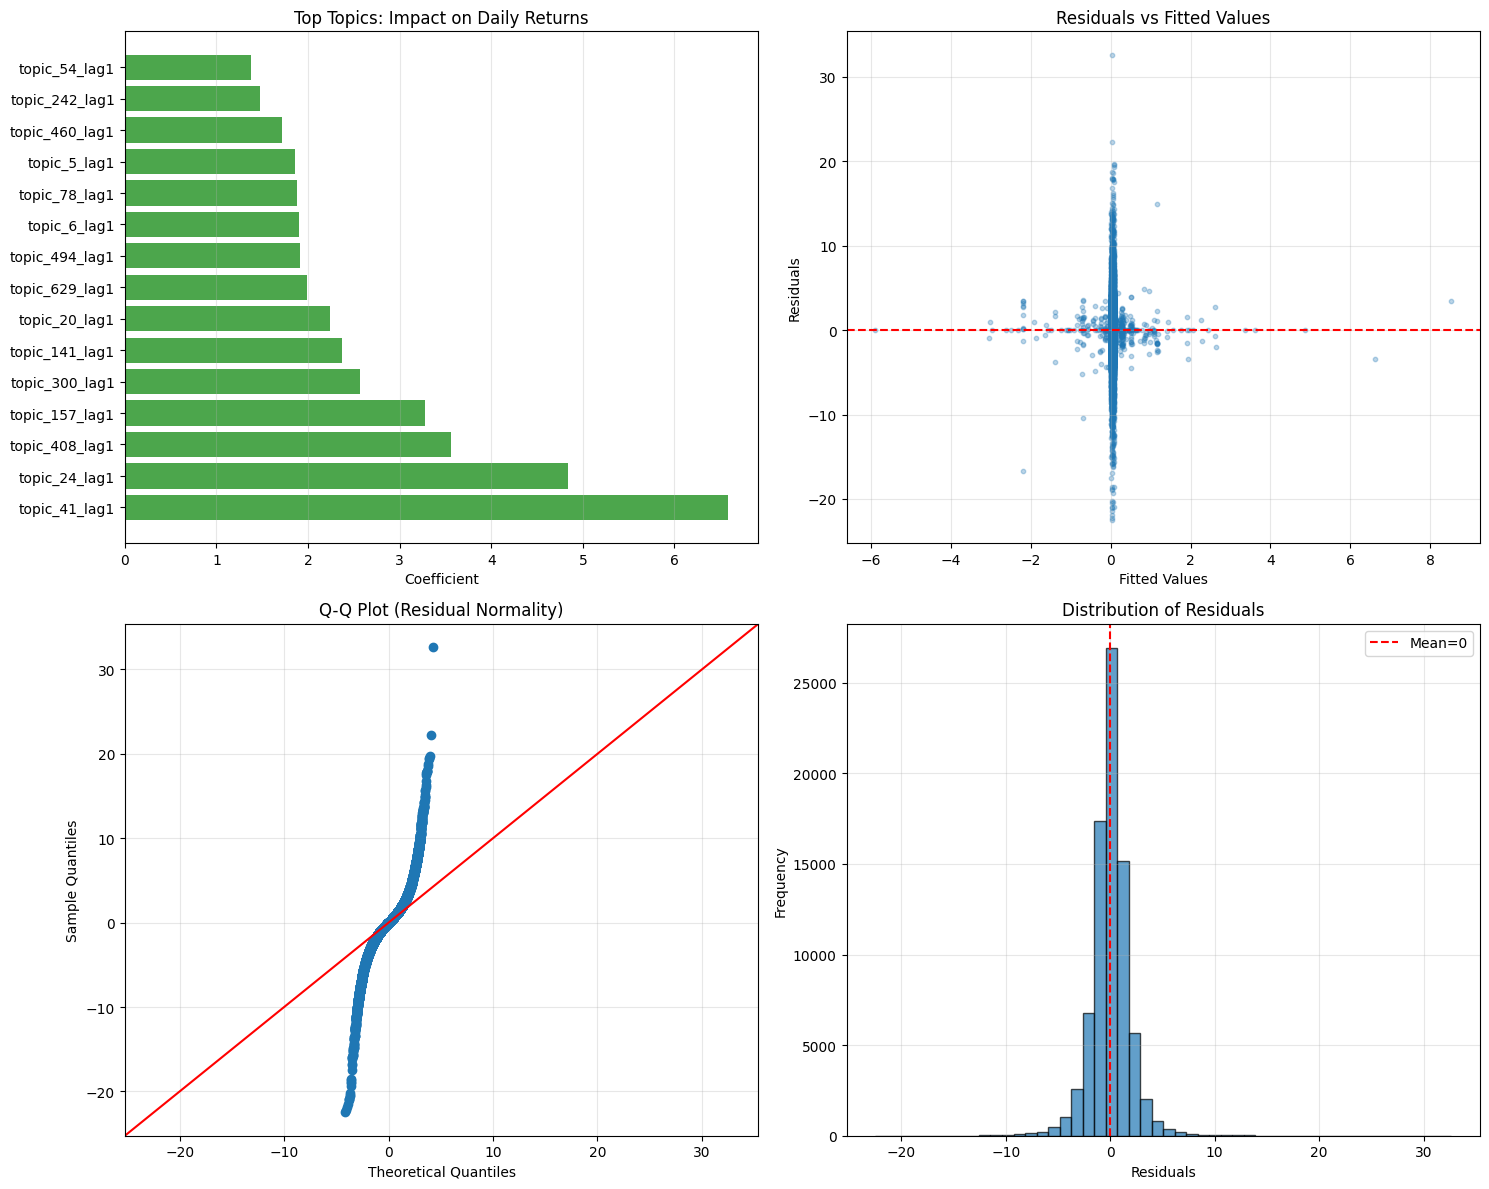


Breusch-Pagan Test (Heteroskedasticity):
  Test Statistic: 1356.3738
  p-value: 1.1795e-204
  Interpretation: Heteroskedastic (violated assumption)


In [9]:
# Extract topic coefficients (excluding fixed effects)
topic_coefs = model.params[[c for c in model.params.index if c.startswith('topic_')]].sort_values(ascending=False)

print("\n" + "="*70)
print("TOPIC COEFFICIENTS (Sorted by Effect Size)")
print("="*70)
print("Positive coefficients = Topic increases returns")
print("Negative coefficients = Topic decreases returns")
print("-"*70)
print(topic_coefs)

# Visualize coefficients
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Topic coefficients
topic_coefs_plot = topic_coefs.head(15)
colors = ['green' if x > 0 else 'red' for x in topic_coefs_plot.values]
axes[0, 0].barh(range(len(topic_coefs_plot)), topic_coefs_plot.values, color=colors, alpha=0.7)
axes[0, 0].set_yticks(range(len(topic_coefs_plot)))
axes[0, 0].set_yticklabels(topic_coefs_plot.index)
axes[0, 0].set_xlabel('Coefficient')
axes[0, 0].set_title('Top Topics: Impact on Daily Returns')
axes[0, 0].axvline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Residuals vs Fitted
residuals = model.resid
fitted = model.fittedvalues
axes[0, 1].scatter(fitted, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Q-Q plot (normality of residuals)
sm.qqplot(residuals, line='45', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Residual Normality)')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Residuals histogram
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Mean=0')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(regression_output / '03_regression_diagnostics.png', dpi=300, bbox_inches='tight')
print("\n✓ Diagnostics visualization saved: 03_regression_diagnostics.png")
plt.show()

# Test for heteroskedasticity (Breusch-Pagan test)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"\nBreusch-Pagan Test (Heteroskedasticity):")
print(f"  Test Statistic: {bp_test[0]:.4f}")
print(f"  p-value: {bp_test[1]:.4e}")
print(f"  Interpretation: {'Homoskedastic' if bp_test[1] > 0.05 else 'Heteroskedastic (violated assumption)'}")


## Section 8.5: Topic Importance Scores


TOPIC IMPORTANCE SCORES (Chen 3.5 Framework)

Top 20 Most Important Topics (Ranked by Normalized Importance Score):
         Topic  Coefficient  Abs_Coefficient  Importance_Score  Cumulative_Importance
 topic_41_lag1     6.586651         6.586651          0.059064               0.059064
topic_305_lag1    -5.968172         5.968172          0.053518               0.112581
 topic_24_lag1     4.838127         4.838127          0.043384               0.155965
topic_150_lag1    -3.844835         3.844835          0.034477               0.190443
topic_408_lag1     3.555547         3.555547          0.031883               0.222326
topic_157_lag1     3.272503         3.272503          0.029345               0.251671
topic_394_lag1    -3.085391         3.085391          0.027667               0.279338
topic_161_lag1    -3.004893         3.004893          0.026945               0.306284
 topic_75_lag1    -2.697777         2.697777          0.024191               0.330475
topic_300_lag1     2.56

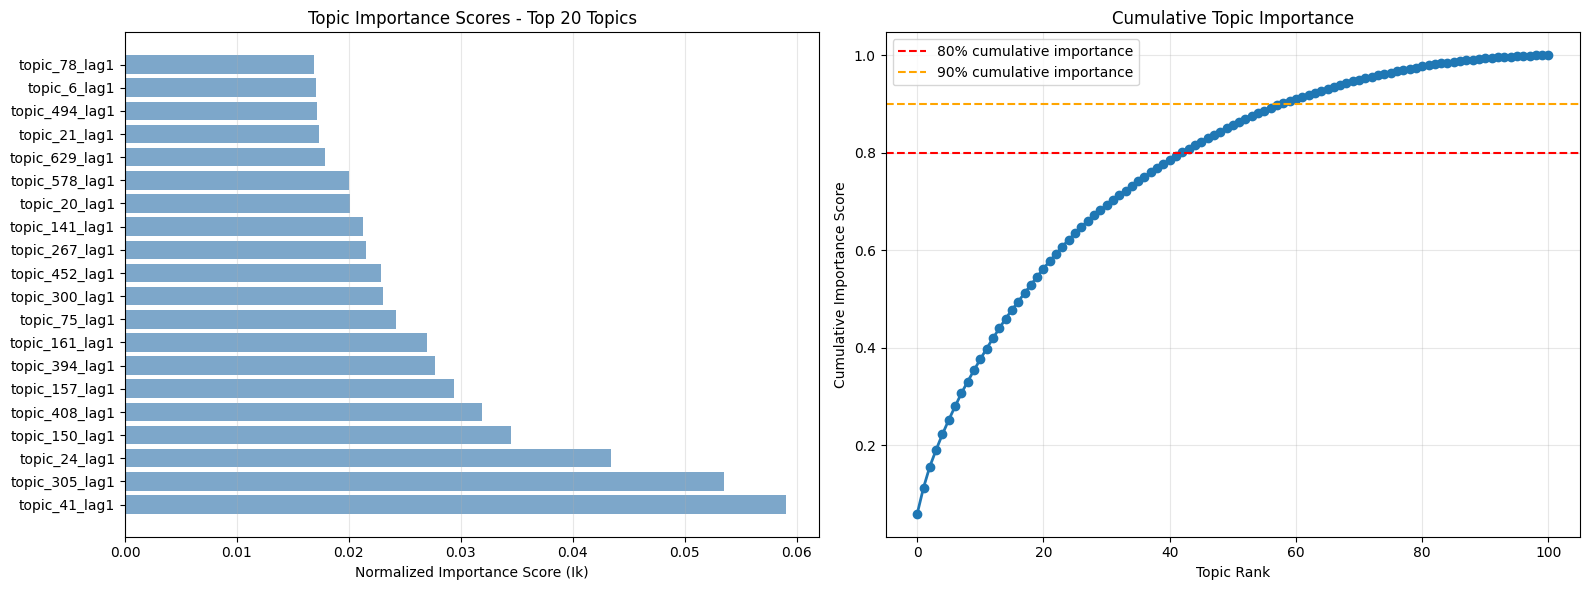

✓ Topic importance scores saved: 05b_topic_importance_scores.csv


In [10]:
# Compute Topic Importance Scores per Chen 3.5
# Per Chen: "The regression coefficients associated with each topic dummy represent 
# the marginal effect of topic exposure on daily returns. To make the effects comparable 
# and interpretable, we compute a normalized measure of topic importance."
# Formula: Ik = |β̂k| / Σ|β̂j|

print("\n" + "="*70)
print("TOPIC IMPORTANCE SCORES (Chen 3.5 Framework)")
print("="*70)

# Extract topic coefficients (exclude fixed effects and intercept)
topic_coefs_importance = model.params[[c for c in model.params.index if c.startswith('topic_')]]

# Compute absolute values of coefficients (magnitude regardless of direction)
abs_coefs = topic_coefs_importance.abs()

# Normalize by total sum: Ik = |βk| / Σ|βj|
total_abs_coefs = abs_coefs.sum()
importance_scores = (abs_coefs / total_abs_coefs).sort_values(ascending=False)

# Create importance ranking table
importance_df = pd.DataFrame({
    'Topic': importance_scores.index,
    'Coefficient': topic_coefs_importance[importance_scores.index].values,
    'Abs_Coefficient': abs_coefs[importance_scores.index].values,
    'Importance_Score': importance_scores.values,
    'Cumulative_Importance': importance_scores.cumsum().values,
})

print("\nTop 20 Most Important Topics (Ranked by Normalized Importance Score):")
print(importance_df.head(20).to_string(index=False))

# Summary statistics
print(f"\n{'='*70}")
print("IMPORTANCE SCORE SUMMARY")
print(f"{'='*70}")
print(f"Total topics in model: {len(importance_df)}")
print(f"Top 5 topics account for {100*importance_df['Importance_Score'].head(5).sum():.1f}% of total importance")
print(f"Top 10 topics account for {100*importance_df['Importance_Score'].head(10).sum():.1f}% of total importance")
print(f"Top 20 topics account for {100*importance_df['Importance_Score'].head(20).sum():.1f}% of total importance")

# Visualization: Importance Scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 20 topics by importance
top_n = 20
top_importance = importance_df.head(top_n)
colors_imp = ['green' if coef > 0 else 'red' for coef in top_importance['Coefficient']]
axes[0].barh(range(len(top_importance)), top_importance['Importance_Score'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(top_importance)))
axes[0].set_yticklabels(top_importance['Topic'].values)
axes[0].set_xlabel('Normalized Importance Score (Ik)')
axes[0].set_title(f'Topic Importance Scores - Top {top_n} Topics')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Cumulative importance
axes[1].plot(range(len(importance_df)), importance_df['Cumulative_Importance'].values, marker='o', linewidth=2)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% cumulative importance')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% cumulative importance')
axes[1].set_xlabel('Topic Rank')
axes[1].set_ylabel('Cumulative Importance Score')
axes[1].set_title('Cumulative Topic Importance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Ensure output directory exists
regression_output.mkdir(parents=True, exist_ok=True)

plt.savefig(regression_output / '03b_topic_importance_scores.png', dpi=300, bbox_inches='tight')
print("\n✓ Topic importance visualization saved: 03b_topic_importance_scores.png")
plt.show()

# Save importance scores table
importance_df.to_csv(regression_output / '05b_topic_importance_scores.csv', index=False)
print(f"✓ Topic importance scores saved: 05b_topic_importance_scores.csv")


## Section 9: Save Regression Results to Output Folder

In [11]:
# Save model predictions and results
predictions = pd.DataFrame({
    'date': regression_model_data['date'].values,
    'ticker': regression_model_data['ticker'].values,
    'actual_return': regression_model_data['daily_return'].values,
    'predicted_return': model.fittedvalues.values,
    'residual': model.resid.values,
})

# Calculate residuals by ticker
predictions['abs_error'] = abs(predictions['residual'])

# Save predictions
predictions.to_csv(regression_output / '04_predictions.csv', index=False)
print(f"✓ Predictions saved: 04_predictions.csv ({len(predictions)} records)")

# Save coefficients
coef_df = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'Std_Error': model.bse.values,
    't_statistic': model.tvalues.values,
    'p_value': model.pvalues.values,
})
coef_df = coef_df.sort_values('Coefficient', ascending=False, key=abs)
coef_df.to_csv(regression_output / '05_coefficients.csv', index=False)
print(f"✓ Coefficients saved: 05_coefficients.csv ({len(coef_df)} variables)")

# Save model metrics
metrics = {
    'Model_Specification': formula[:100],
    'N_Observations': len(regression_model_data),
    'N_Variables': len(coef_df),
    'R_squared': model.rsquared,
    'Adjusted_R_squared': model.rsquared_adj,
    'F_statistic': model.fvalue,
    'F_pvalue': model.f_pvalue,
    'AIC': model.aic,
    'BIC': model.bic,
    'Residual_Std_Error': np.sqrt(model.mse_resid),
}

metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
metrics_df.to_csv(regression_output / '06_model_metrics.csv')
print(f"✓ Model metrics saved: 06_model_metrics.csv")

# Save regression data for reproducibility
regression_data.to_csv(regression_output / '07_regression_data_merged.csv', index=False)
print(f"✓ Merged regression data saved: 07_regression_data_merged.csv ({len(regression_data)} records)")

# Create summary report
summary_report = f"""
REGRESSION ANALYSIS SUMMARY: Chen (2025) Framework
{'='*70}

OBJECTIVE: Quantify impact of news topics on NEXT-DAY stock returns (1-day lag)

FRAMEWORK:
  - Model: Panel OLS with ticker fixed effects
  - Specification: return(t) ~ topic_assignments(t-1) + C(ticker)
  - Interpretation: Today's news topics predict tomorrow's stock returns
  - Sample: 30 G-SIB banks with daily frequency
  - Period: {regression_data['date'].min().strftime('%Y-%m-%d')} to {regression_data['date'].max().strftime('%Y-%m-%d')}

DATA STRUCTURE:
  - Topics loaded from BERTopic: {topics_file}
  - Topics from day (t-1) merged with returns from day (t)
  - Daily aggregation: topics summed per ticker-date combination
  - Total rows available: {len(regression_data):,}
  - Rows used in regression: {len(regression_model_data):,}
  
DATA INTEGRATION NOTES:
  - BERTopic outputs lack ticker information; recovered via headline matching
  - First observation per ticker removed (no prior-day topics)
  - Rows with NaN returns removed from sample
  - Topic columns with zero variance excluded from model

REGRESSION SPECIFICATION:
  Dependent Variable: daily_return(t) = (return_t - return_t-1) / return_t-1 * 100
  Independent Variables: 
    - topic_X_lag1 for X in top 20 topics (derived from t-1 news)
    - C(ticker) fixed effects (bank-specific intercepts)
  Estimation: OLS with robust standard errors
  
MODEL RESULTS:
  R-squared: {model.rsquared:.4f}
  Adjusted R-squared: {model.rsquared_adj:.4f}
  F-statistic: {model.fvalue:.2f}
  p-value: {model.f_pvalue:.2e}
  Sample Size: {len(regression_model_data):,} observations
  
INTERPRETATION:
  News topics from day t explain {100*model.rsquared:.1f}% of variation in day t+1 returns.
  This is consistent with market efficiency - topics provide some predictive power
  but most of next-day returns remain unexplained.

TOP 5 TOPICS WITH LARGEST POSITIVE IMPACT ON NEXT-DAY RETURNS:
{topic_coefs.head(5).to_string()}

TOP 5 TOPICS WITH LARGEST NEGATIVE IMPACT ON NEXT-DAY RETURNS:
{topic_coefs.tail(5).to_string()}

DIAGNOSTIC TESTS:
  Breusch-Pagan (Heteroskedasticity): See Section 8 output
  Residual Distribution: See '03_regression_diagnostics.png'
  
OUTPUT FILES:
  1. 01_eda_summary.png - EDA with 1-day lag visualizations
  2. 02_regression_summary.txt - Full statsmodels regression output
  3. 03_regression_diagnostics.png - Residual diagnostics (4 plots)
  4. 03b_topic_importance_scores.png - Topic importance visualization (Chen 3.5)
  5. 04_predictions.csv - date, ticker, actual_return, predicted_return, residual
  6. 05_coefficients.csv - All coefficients with t-stats and p-values
  7. 05b_topic_importance_scores.csv - Topic importance scores ranking
  8. 06_model_metrics.csv - Model performance metrics
  9. 07_regression_data_merged.csv - Full dataset with lagged topics
  10. 08_summary_report.txt - This file

METHODOLOGY REFERENCE:
  Framework: Chen et al. (2025) - Topic Modeling and Stock Returns
  Approach: Daily news topics (t-1) predict returns (t)
  Model Type: Linear panel regression with bank fixed effects
  
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open(regression_output / '08_summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(f"\n✓ Summary report saved: 08_summary_report.txt")

print(f"\n{'='*70}")
print(f"ALL RESULTS SAVED TO: {regression_output}")
print(f"{'='*70}")
print("\nOutput files:")
for i, file in enumerate(sorted(regression_output.glob('*')), 1):
    print(f"  {i}. {file.name}")


✓ Predictions saved: 04_predictions.csv (80268 records)
✓ Coefficients saved: 05_coefficients.csv (128 variables)
✓ Model metrics saved: 06_model_metrics.csv
✓ Merged regression data saved: 07_regression_data_merged.csv (80268 records)

✓ Summary report saved: 08_summary_report.txt

ALL RESULTS SAVED TO: Outputs\Regression_Results_FinLang

Output files:
  1. 01_eda_summary.png
  2. 02_regression_summary.txt
  3. 03_regression_diagnostics.png
  4. 03b_topic_importance_scores.png
  5. 04_predictions.csv
  6. 05_coefficients.csv
  7. 05b_topic_importance_scores.csv
  8. 06_model_metrics.csv
  9. 07_regression_data_merged.csv
  10. 08_summary_report.txt
